In [1]:
import numpy as np
import scipy.optimize as optimize
import matplotlib.pyplot as plt
from tqdm import tqdm

# all the required function for the differents benchmark

def generate_8sat_clauses(n, m):
    """Generates random 8-SAT clauses.
        output list of tupples (indexes,sign)"""
    clauses = []
    for _ in range(m):
        vars_idx = np.random.choice(n, K_SAT, replace=True)
        literals = np.random.randint(0, 2, size=K_SAT)
        clauses.append((vars_idx, literals))
    return clauses

def get_exact_sat_solutions(n, clauses):
    """Finds exact solutions (Energy = 0) classically.
        output bitstring of sols"""
    num_states = 2**n
    violation_counts = np.zeros(num_states, dtype=np.int32)
    states = np.arange(num_states, dtype=np.int32)
    for vars_idx, is_negated_list in clauses:
        clause_violated_mask = np.ones(num_states, dtype=bool)
        for i, v_idx in enumerate(vars_idx):
            target_bit = int(is_negated_list[i])
            bit_val = (states >> v_idx) & 1
            clause_violated_mask &= (bit_val == target_bit)
        violation_counts[clause_violated_mask] += 1
    return np.where(violation_counts == 0)[0]

def get_hamiltonian_diagonal(n, clauses):
    """Precomputes the diagonal of H_C."""
    num_states = 2**n
    diagonal = np.zeros(num_states, dtype=np.float64)
    states = np.arange(num_states, dtype=np.int32)
    for vars_idx, literals in clauses:
        violation_mask = np.ones(num_states, dtype=bool)
        for i, v_idx in enumerate(vars_idx):
            target_bit = literals[i]
            bit_val = (states >> v_idx) & 1
            violation_mask &= (bit_val == target_bit)
        diagonal[violation_mask] += 1.0
    return diagonal

def get_lr_params(deltas, p):
    """Expands 2 parameters (dg, db) into 2p parameters via linear ramp."""
    dg, db = deltas
    k = np.arange(1, p + 1)
    gammas = dg * (k / p)
    betas = db * (1.0 - k / p)
    return np.concatenate([gammas, betas])

def simulate_qaoa_fast(params, n, h_diag, p):
    """Fast Numpy Simulator for QAOA Statevector."""
    num_states = 2**n
    gammas = params[:p]
    betas = params[p:]
    psi = np.ones(num_states, dtype=np.complex128) / np.sqrt(num_states)
    indices = np.arange(num_states)
    
    for t in range(p):
        psi *= np.exp(-1j * gammas[t] * h_diag)
        beta = betas[t]
        c = np.cos(beta)
        s = -1j * np.sin(beta)
        for qubit in range(n):
            mask_0 = (indices >> qubit) & 1 == 0
            idx0 = indices[mask_0]
            idx1 = idx0 + (1 << qubit)
            u0 = psi[idx0]
            u1 = psi[idx1]
            psi[idx0] = c * u0 + s * u1
            psi[idx1] = s * u0 + c * u1
    return np.abs(psi)**2

# --- 2. Training Phase ---

def generate_training_set():
    print(f"Generating training set (n={TRAIN_N}, size={TRAIN_SIZE})...")
    data = []
    lambda_val = CLAUSE_DENSITY * TRAIN_N
    while len(data) < TRAIN_SIZE:
        m = max(1, np.random.poisson(lam=lambda_val))
        clauses = generate_8sat_clauses(TRAIN_N, m)
        sol_indices = get_exact_sat_solutions(TRAIN_N, clauses)
        if len(sol_indices) > 0:
            h_diag = get_hamiltonian_diagonal(TRAIN_N, clauses)
            data.append((h_diag, sol_indices))
    return data

def train_full_model(training_data):
    print("\n--- Training Full QAOA (Small Angle Init) ---")
    def objective(pars):
        total_p = 0.0
        for h_diag, sol_indices in training_data:
            probs = simulate_qaoa_fast(pars, TRAIN_N, h_diag, P_DEPTH)
            total_p += np.sum(probs[sol_indices])
        return -1.0 * (total_p / len(training_data))

    # Paper Strategy: Initialize close to zero
    x0 = np.concatenate([np.full(P_DEPTH, -0.01), np.full(P_DEPTH, 0.01)])
    
    res = optimize.minimize(objective, x0, method='COBYLA', tol=1e-3, options={'maxiter': 600})
    print(f"  > Full QAOA Train Avg Prob: {-res.fun:.4f}")
    return res.x

def train_lr_grid_search(training_data,depth,skip_grid=False):
    print("\n--- Training LR QAOA (Grid Search Init) ---")
    
    def get_avg_p_succ(dg, db):
        pars = get_lr_params([dg, db], depth)
        total_p = 0.0
        for h_diag, sol_indices in training_data:
            probs = simulate_qaoa_fast(pars, TRAIN_N, h_diag, depth)
            total_p += np.sum(probs[sol_indices])
        return total_p / len(training_data)

    # 1. Grid Search
    # Scanning widely to find the correct basin of attraction
    dg_vals = np.linspace(-2.0, 2.0, 11) 
    db_vals = np.linspace(0.1, 4.0, 11) 
    
    best_p = -1.0
    best_deltas = [-0.8, 0.49]
    
    if not(skip_grid):
        for dg in tqdm(dg_vals, desc="Grid Scanning"):
            for db in db_vals:
                p_val = get_avg_p_succ(dg, db)
                if p_val > best_p:
                    best_p = p_val
                    best_deltas = [dg, db]
                
    print(f"  > Best Grid Start: dg={best_deltas[0]:.2f}, db={best_deltas[1]:.2f} (Prob={best_p:.4f})")
    
    # 2. Refinement
    def objective(d): return -1.0 * get_avg_p_succ(d[0], d[1])
    
    res = optimize.minimize(objective, best_deltas, method='COBYLA', tol=1e-3, options={'maxiter': 200})
    print(f"  > LR QAOA Train Avg Prob: {-res.fun:.4f}")
    
    return get_lr_params(res.x, depth)

# --- 3. Comparative Evaluation ---

import numpy as np
from tqdm import tqdm

def generate_benchmark_instances(n_range, test_size, clause_density):
    dataset = {}
    
    print(f"\n--- Generating Benchmark Dataset (n={list(n_range)}) ---")
    
    for n in n_range:
        lambda_val = clause_density * n
        instances = []
        valid_count = 0
        
        with tqdm(total=test_size, desc=f"Generating n={n}", leave=False) as pbar:
            while valid_count < test_size:
                # Generate random clause count based on Poisson distribution
                m = max(1, np.random.poisson(lam=lambda_val))
                clauses = generate_8sat_clauses(n, m)
                
                # Identify solutions; filtering for SAT instances only
                sol_indices = get_exact_sat_solutions(n, clauses)
                
                if len(sol_indices) == 0:
                    continue
                
                # Pre-compute Hamiltonian diagonal to save time during evaluation
                h_diag = get_hamiltonian_diagonal(n, clauses)
                
                instances.append({
                    'clauses': clauses,
                    'sol_indices': sol_indices,
                    'h_diag': h_diag
                })
                
                valid_count += 1
                pbar.update(1)
        
        dataset[n] = instances
    return dataset

def evaluate_model(dataset, params_lr, p_depth):
    print(f"\n--- Comparative Evaluation (LR Params) ---")
    results = {'n': [], 'lr_runtime': []}
    
    # Sort keys to ensure sequential processing
    n_values = sorted(dataset.keys())
    
    for n in n_values:
        instances = dataset[n]
        runtimes_lr = []
        
        # Iterate through the pre-generated instances
        for instance in tqdm(instances, desc=f"Benchmarking n={n}", leave=False):
            h_diag = instance['h_diag']
            sol_indices = instance['sol_indices']
            
            # Simulate QAOA using the provided Linear Response parameters
            probs_lr = simulate_qaoa_fast(params_lr, n, h_diag, p_depth)
            
            # Calculate overlap with solution subspace
            # Added epsilon 1e-15 to prevent division by zero in runtime calculation
            p_lr = max(np.sum(probs_lr[sol_indices]), 1e-15)
            
            # Metric: Expected number of shots to observe a solution (1/p)
            runtimes_lr.append(1.0 / p_lr)
            
        med_lr = np.median(runtimes_lr)
        
        results['n'].append(n)
        results['lr_runtime'].append(med_lr)
        
        tqdm.write(f"n={n}: Median Runtime (1/p) = {med_lr:.2f}")
            
    return results

def fit_scaling(n, y):
    log_y = np.log(y)
    slope, intercept = np.polyfit(n, log_y, 1)
    return np.exp(intercept), slope

import numpy as np
import random
from tqdm import tqdm


def run_walksat_specific(n, clauses, max_flips, p_noise):
    """
    WalkSAT solver adapted for the specific tuple structure: (vars_idx, signs).
    
    Args:
        n (int): Number of variables.
        clauses (list): List of tuples [(vars_idx, signs), ...].
        max_flips (int): Max steps.
        p_noise (float): Probability of random move.
        
    Returns:
        int: Number of flips used (or max_flips if failed).
    """
    # 1. Initialize Assignment (0 or 1)
    # Using 0-based indexing to match np.random.choice(n)
    assignment = np.random.randint(2, size=n)
    
    for flip in range(1, max_flips + 1):
        
        # --- A. Identify Unsatisfied Clauses ---
        unsat_indices = []
        
        for i, (vars_idx, signs) in enumerate(clauses):
            # A clause is SAT if at least one literal matches the assignment
            # signs[k] is the required value for assignment[vars_idx[k]]
            
            # Fast vectorized check:
            # vars_idx selects the current values from assignment
            # We compare them to signs. If any match, it's SAT.
            if not np.any(assignment[vars_idx] == signs):
                unsat_indices.append(i)
        
        # --- B. Check Success ---
        if not unsat_indices:
            return flip
            
        # --- C. Pick Random Unsatisfied Clause ---
        target_clause_idx = random.choice(unsat_indices)
        target_vars, target_signs = clauses[target_clause_idx]
        
        # --- D. Select Variable to Flip ---
        var_to_flip = -1
        
        if random.random() < p_noise:
            # Random Walk: Pick a random variable index from the clause
            var_to_flip = random.choice(target_vars)
        else:
            # Greedy Step: Find variable that minimizes total unsatisfied clauses
            best_var = target_vars[0]
            min_unsat = float('inf')
            
            # We only check variables present in the target clause
            # (Note: Using np.unique in case variables repeat in the clause)
            candidates = np.unique(target_vars)
            
            for var in candidates:
                # Flip experimentally
                assignment[var] = 1 - assignment[var]
                
                # Count current global unsatisfied (Linear scan - simple but slow)
                current_unsat_count = 0
                for v_idx, s in clauses:
                    if not np.any(assignment[v_idx] == s):
                        current_unsat_count += 1
                        
                if current_unsat_count < min_unsat:
                    min_unsat = current_unsat_count
                    best_var = var
                    
                # Flip back
                assignment[var] = 1 - assignment[var]
            
            var_to_flip = best_var

        # --- E. Perform Flip ---
        assignment[var_to_flip] = 1 - assignment[var_to_flip]

    return max_flips

def evaluate_model_walksat(dataset, max_flips=100000, p_noise=0.5):
    """
    Evaluates WalkSAT on the specific dataset format.
    """
    print(f"\n--- Comparative Evaluation: WalkSAT (p={p_noise}) ---")
    results = {'n': [], 'median_runtime': []}
    
    n_values = sorted(dataset.keys())
    
    for n in n_values:
        instances = dataset[n]
        runtimes = []
        
        for instance in tqdm(instances, desc=f"Benchmarking n={n}", leave=False):
            clauses = instance['clauses']
            
            # Pass N and the clauses list directly
            flips = run_walksat_specific(n, clauses, max_flips, p_noise)
            runtimes.append(flips)
            
        med_val = np.median(runtimes)
        results['n'].append(n)
        results['median_runtime'].append(med_val)
        
        tqdm.write(f"n={n}: Median Runtime = {med_val:.2f} flips")
        
    return results

import numpy as np
import random
from tqdm import tqdm

def run_walksatlm_bench(n, clauses, max_flips, p_noise):
    """
    Executes WalkSATlm (Linear Make) on a single instance.
    
    Logic:
    1. If a variable has break=0 (Free Move), flip it.
    2. Else with prob p_noise, pick random variable from clause.
    3. Else (Greedy), pick variable with MINIMUM break. 
       If ties exist, pick the one with MAXIMUM make (Linear Make).
    """
    # 0. Pre-processing: Build Adjacency List (Critical for speed)
    # adj[v] = list of clause indices where variable v appears
    adj = [[] for _ in range(n)]
    for i, (vars_idx, signs) in enumerate(clauses):
        unique_vars = np.unique(vars_idx)
        for v in unique_vars:
            adj[v].append(i)

    # 1. Initialization
    assignment = np.random.randint(2, size=n)
    
    # Track status of all clauses to avoid re-evaluating everything
    clause_status = np.zeros(len(clauses), dtype=bool)
    
    # Initial evaluation
    for i, (vars_idx, signs) in enumerate(clauses):
        if np.any(assignment[vars_idx] == signs):
            clause_status[i] = True
            
    # 2. Search Loop
    for flip in range(1, max_flips + 1):
        
        # A. Get Unsatisfied Clauses
        unsat_indices = np.where(~clause_status)[0]
        
        if len(unsat_indices) == 0:
            return flip # Solved
            
        # B. Pick Random Unsatisfied Clause
        target_clause_idx = np.random.choice(unsat_indices)
        target_vars, _ = clauses[target_clause_idx]
        
        # Candidates are the variables in this clause
        candidates = np.unique(target_vars)
        
        # C. Evaluate Candidates (Compute Break & Make)
        # We need to find if there is a 'break=0' variable, 
        # and otherwise gather metrics for tie-breaking.
        
        best_break_0_var = -1
        candidate_metrics = [] # List of (var, break, make)
        
        # Optimization: Only calculate metrics if we don't do a random walk immediately?
        # Standard WalkSATlm checks for break=0 *before* random walk.
        
        for var in candidates:
            current_break = 0
            current_make = 0
            
            # Flip experimentally
            assignment[var] = 1 - assignment[var]
            
            # Check only affected clauses
            for c_idx in adj[var]:
                c_vars, c_signs = clauses[c_idx]
                is_sat = np.any(assignment[c_vars] == c_signs)
                was_sat = clause_status[c_idx]
                
                if was_sat and not is_sat:
                    current_break += 1
                elif not was_sat and is_sat:
                    current_make += 1
            
            # Flip back
            assignment[var] = 1 - assignment[var]
            
            if current_break == 0:
                best_break_0_var = var
                break # Found free move
            
            candidate_metrics.append((var, current_break, current_make))
            
        # D. Decision
        var_to_flip = -1
        
        if best_break_0_var != -1:
            var_to_flip = best_break_0_var
        elif random.random() < p_noise:
            # Random Walk
            var_to_flip = random.choice(candidates)
        else:
            # Greedy with Linear Make Tie-Breaking
            # Sort: Primary key = Break (Ascending), Secondary key = Make (Descending)
            candidate_metrics.sort(key=lambda x: (x[1], -x[2]))
            var_to_flip = candidate_metrics[0][0]

        # E. Perform Flip
        assignment[var_to_flip] = 1 - assignment[var_to_flip]
        
        # Update statuses efficiently
        for c_idx in adj[var_to_flip]:
            c_vars, c_signs = clauses[c_idx]
            clause_status[c_idx] = np.any(assignment[c_vars] == c_signs)

    return max_flips

def evaluate_model_walksatlm(dataset, max_flips=100000, p_noise=0.5):
    """
    Evaluates WalkSATlm (Linear Make) on the generated 8-SAT dataset.
    """
    print(f"\n--- Comparative Evaluation: WalkSATlm (p={p_noise}) ---")
    results = {'n': [], 'walksatlm_runtime': []}
    
    n_values = sorted(dataset.keys())
    
    for n in n_values:
        instances = dataset[n]
        runtimes = []
        
        for instance in tqdm(instances, desc=f"Benchmarking n={n}", leave=False):
            clauses = instance['clauses']
            
            # Run WalkSATlm
            flips = run_walksatlm_bench(n, clauses, max_flips, p_noise)
            runtimes.append(flips)
            
        med_runtime = np.median(runtimes)
        
        results['n'].append(n)
        results['walksatlm_runtime'].append(med_runtime)
        
        tqdm.write(f"n={n}: Median Runtime = {med_runtime:.2f} flips")
            
    return results

import numpy as np
from numba import njit
from tqdm import tqdm
import random

# --- JIT Compiled Solver (Runs at C-speed) ---
@njit
def fast_walksat_solver(n, clause_vars, clause_signs, max_flips, p_noise):
    """
    Numba-optimized WalkSAT solver.
    Operates on rigid 2D arrays instead of lists of tuples.
    """
    # Initialize assignment (0 or 1)
    assignment = np.random.randint(0, 2, n)
    
    # Pre-allocate array for unsatisfied clause indices to avoid list appending overhead
    m = clause_vars.shape[0]
    unsat_buffer = np.empty(m, dtype=np.int32)
    
    for flip in range(max_flips):
        
        # 1. Identify Unsatisfied Clauses (Fast Scan)
        unsat_count = 0
        for i in range(m):
            is_sat = False
            for k in range(8): # K=8 (Fixed for 8-SAT)
                # var index
                v = clause_vars[i, k]
                # required sign (0 or 1)
                s = clause_signs[i, k]
                
                if assignment[v] == s:
                    is_sat = True
                    break
            
            if not is_sat:
                unsat_buffer[unsat_count] = i
                unsat_count += 1
        
        # 2. Check Success
        if unsat_count == 0:
            return flip + 1
        
        # 3. Pick Random Unsatisfied Clause
        # Numba doesn't support random.choice on arrays, so we use index
        rand_idx = np.random.randint(0, unsat_count)
        target_c_idx = unsat_buffer[rand_idx]
        
        # 4. Select Variable to Flip
        var_to_flip = -1
        
        # Random float check
        if np.random.random() < p_noise:
            # Random Walk: Pick random literal 0..7
            rand_lit_idx = np.random.randint(0, 8)
            var_to_flip = clause_vars[target_c_idx, rand_lit_idx]
        else:
            # Greedy: Minimize breaks
            # We must iterate over the 8 variables in the target clause
            best_var = -1
            min_breaks = 999999
            
            for k in range(8):
                candidate_var = clause_vars[target_c_idx, k]
                
                # Flip experimentally
                assignment[candidate_var] = 1 - assignment[candidate_var]
                
                # Count breaks (how many clauses become UNSAT)
                # Optimization: In heavy implementation, we'd use adjacency lists.
                # In this "Simple+Fast" version, we assume M is small enough for Numba to scan.
                current_breaks = 0
                
                # We assume we only care about the candidate's break score.
                # A full global scan is O(M), which is okay in Numba for M<2000.
                for i_scan in range(m):
                    # Check if clause i_scan is UNSAT
                    c_sat = False
                    for k_scan in range(8):
                        v_scan = clause_vars[i_scan, k_scan]
                        s_scan = clause_signs[i_scan, k_scan]
                        if assignment[v_scan] == s_scan:
                            c_sat = True
                            break
                    if not c_sat:
                        current_breaks += 1
                
                if current_breaks < min_breaks:
                    min_breaks = current_breaks
                    best_var = candidate_var
                
                # Flip back
                assignment[candidate_var] = 1 - assignment[candidate_var]
            
            var_to_flip = best_var
            
        # 5. Perform Flip
        assignment[var_to_flip] = 1 - assignment[var_to_flip]
        
    return max_flips

def evaluate_model_walksat_fast(dataset, max_flips=100000, p_noise=0.5):
    """
    High-performance evaluation using Numba.
    Converts data structures to numpy matrices before solving.
    """
    print(f"\n--- Comparative Evaluation: WalkSAT (Numba Accelerated) ---")
    results = {'n': [], 'median_runtime': []}
    
    n_values = sorted(dataset.keys())
    
    for n in n_values:
        instances = dataset[n]
        runtimes = []
        
        for instance in tqdm(instances, desc=f"Benchmarking n={n}", leave=False):
            # 1. Convert specific tuple-list format to rigid Numpy Matrices for Numba
            # Structure: List of (vars_idx_array, signs_array)
            clauses_raw = instance['clauses']
            m = len(clauses_raw)
            
            # Allocate (M, 8) matrices
            # We assume K=8 based on your problem
            c_vars = np.zeros((m, 8), dtype=np.int32)
            c_signs = np.zeros((m, 8), dtype=np.int32)
            
            for i, (v_idx, signs) in enumerate(clauses_raw):
                c_vars[i, :] = v_idx
                c_signs[i, :] = signs
            
            # 2. Run Numba Solver
            flips = fast_walksat_solver(n, c_vars, c_signs, max_flips, p_noise)
            runtimes.append(flips)
            
        med_val = np.median(runtimes)
        results['n'].append(n)
        results['median_runtime'].append(med_val)
        
        tqdm.write(f"n={n}: Median Runtime = {med_val:.2f}")
        
    return results

import numpy as np
import random
from tqdm import tqdm
from numba import njit

@njit
def walksatlm_paper_kernel(n, c_vars, c_signs, max_flips, p_noise, w1, w2):
    """
    Implements WalkSATlm exactly as described in Algorithm 1 of the paper.
    Uses 'num_true_lits' array to track clause states efficiently.
    """
    m = c_vars.shape[0]
    k_sat = c_vars.shape[1] # 8
    
    # --- 1. Build Adjacency Structures ---
    # We need to look up which clauses a variable appears in, 
    # AND what its sign is in that clause (to know if it's True or False).
    
    # Calculate degrees
    degrees = np.zeros(n, dtype=np.int32)
    for i in range(m):
        for k in range(k_sat):
            v = c_vars[i, k]
            degrees[v] += 1
            
    max_degree = 0
    for i in range(n):
        if degrees[i] > max_degree:
            max_degree = degrees[i]
            
    # Fill Adjacency: adj_vars[v] = [clause_idx, ...]
    #                 adj_signs[v] = [sign_in_clause, ...]
    adj_indices = np.full((n, max_degree), -1, dtype=np.int32)
    adj_signs = np.full((n, max_degree), -1, dtype=np.int32)
    current_fill = np.zeros(n, dtype=np.int32)
    
    for i in range(m):
        for k in range(k_sat):
            v = c_vars[i, k]
            s = c_signs[i, k]
            
            # Uniqueness check to handle variables appearing twice in a clause
            # (Though in standard benchmarks, usually variables are unique in clause)
            # We add it anyway for safety.
            pos = current_fill[v]
            adj_indices[v, pos] = i
            adj_signs[v, pos] = s
            current_fill[v] += 1

    # --- 2. Initialization ---
    assignment = np.random.randint(0, 2, n)
    
    # Track number of true literals per clause (Critical for Make_1 vs Make_2)
    num_true_lits = np.zeros(m, dtype=np.int32)
    
    for i in range(m):
        count = 0
        for k in range(k_sat):
            if assignment[c_vars[i, k]] == c_signs[i, k]:
                count += 1
        num_true_lits[i] = count

    # Buffer for unsatisfied clauses
    unsat_buffer = np.empty(m, dtype=np.int32)

    # --- 3. Main Loop ---
    for flip in range(1, max_flips + 1):
        
        # A. Find Unsatisfied Clauses
        unsat_count = 0
        for i in range(m):
            if num_true_lits[i] == 0:
                unsat_buffer[unsat_count] = i
                unsat_count += 1
        
        if unsat_count == 0:
            return flip # Solved
            
        # B. Pick Clause C randomly
        rand_idx = np.random.randint(0, unsat_count)
        target_c_idx = unsat_buffer[rand_idx]
        
        # Candidates are variables in C
        candidates = c_vars[target_c_idx]
        
        # C. Calculate Properties for Candidates (Break, Make1, Make2)
        # We need to find "best" variable according to paper logic.
        
        # Paper logic:
        # 1. Identify set of vars with Break=0. If exists, pick max lmake.
        # 2. Else:
        #    - Prob p: Random
        #    - Prob 1-p: Min Break, tie-break max lmake.
        
        # To do this efficiently, we gather metrics for all candidates first.
        # Max K=8, so fixed size arrays are fast.
        
        cand_breaks = np.zeros(k_sat, dtype=np.int32)
        cand_lmakes = np.zeros(k_sat, dtype=np.int32)
        
        has_zero_break = False
        
        for k in range(k_sat):
            var = candidates[k]
            
            current_break = 0
            make_1 = 0
            make_2 = 0
            
            # Iterate clauses containing 'var'
            deg = current_fill[var]
            for idx in range(deg):
                c_idx = adj_indices[var, idx]
                s = adj_signs[var, idx]
                
                # Check clause state
                lit_count = num_true_lits[c_idx]
                
                # If var is currently True in this clause (assignment == s)
                # Flipping makes it False.
                if assignment[var] == s:
                    # If it was the ONLY true literal, we break the clause.
                    if lit_count == 1:
                        current_break += 1
                        
                # If var is currently False in this clause (assignment != s)
                # Flipping makes it True.
                else:
                    # If clause was unsatisfied (0 true), it becomes 1-true. -> Make_1
                    if lit_count == 0:
                        make_1 += 1
                    # If clause was 1-true, it becomes 2-true. -> Make_2
                    elif lit_count == 1:
                        make_2 += 1
            
            cand_breaks[k] = current_break
            # lmake formula 
            cand_lmakes[k] = (w1 * make_1) + (w2 * make_2)
            
            if current_break == 0:
                has_zero_break = True

        # D. Selection Logic 
        best_var = -1
        
        if has_zero_break:
            # "If variable x in C with break(x)=0 then v <- x, breaking ties by greatest lmake"
            best_val = -1e9
            
            for k in range(k_sat):
                if cand_breaks[k] == 0:
                    score = cand_lmakes[k]
                    if score > best_val:
                        best_val = score
                        best_var = candidates[k]
                    elif score == best_val:
                        # Further ties random (Paper: "breaking ties by ... greatest lmake" 
                        # does not specify 2nd tier ties, usually random)
                        if np.random.random() < 0.5:
                            best_var = candidates[k]
                            
        else:
            # No zero break variable
            if np.random.random() < p_noise:
                # "With probability p: v <- a variable in C chosen at random"
                rand_k = np.random.randint(0, k_sat)
                best_var = candidates[rand_k]
            else:
                # "With probability 1-p: v <- variable with minimum break, breaking ties by greatest lmake"
                min_b = 999999
                max_l = -999999
                
                for k in range(k_sat):
                    b = cand_breaks[k]
                    l = cand_lmakes[k]
                    
                    if b < min_b:
                        min_b = b
                        max_l = l
                        best_var = candidates[k]
                    elif b == min_b:
                        # Tie on break, check lmake
                        if l > max_l:
                            max_l = l
                            best_var = candidates[k]
                        elif l == max_l:
                            # Tie on both
                            if np.random.random() < 0.5:
                                best_var = candidates[k]

        # E. Perform Flip
        # We must update assignment AND num_true_lits for all affected clauses
        assignment[best_var] = 1 - assignment[best_var]
        
        deg = current_fill[best_var]
        for idx in range(deg):
            c_idx = adj_indices[best_var, idx]
            s = adj_signs[best_var, idx]
            
            # If sign matches new assignment, we became True (count +1)
            # If sign mismatches new assignment, we became False (count -1)
            if assignment[best_var] == s:
                num_true_lits[c_idx] += 1
            else:
                num_true_lits[c_idx] -= 1

    return max_flips

def evaluate_model_walksatlm(dataset, max_flips=100000, p_noise=0.5, w1=6, w2=5):
    """
    Evaluates the Paper-Correct WalkSATlm on the dataset.
    """
    print(f"\n--- Comparative Evaluation: WalkSATlm (Paper Version, w1={w1}, w2={w2}) ---")
    results = {'n': [], 'median_runtime': []}
    
    n_values = sorted(dataset.keys())
    
    for n in n_values:
        instances = dataset[n]
        runtimes = []
        
        for instance in tqdm(instances, desc=f"Benchmarking n={n}", leave=False):
            # Prepare data for Numba
            clauses_raw = instance['clauses']
            m = len(clauses_raw)
            c_vars = np.zeros((m, 8), dtype=np.int32)
            c_signs = np.zeros((m, 8), dtype=np.int32)
            
            for i, (v_idx, signs) in enumerate(clauses_raw):
                c_vars[i, :] = v_idx
                c_signs[i, :] = signs
            
            # Run Solver
            flips = walksatlm_paper_kernel(n, c_vars, c_signs, max_flips, p_noise, w1, w2)
            runtimes.append(flips)
            
        med_val = np.median(runtimes)
        results['n'].append(n)
        results['median_runtime'].append(med_val)
        
        tqdm.write(f"n={n}: Median Runtime = {med_val:.2f}")
        
    return results

In [4]:
TRAIN_N = 12            # Train on n=12 (like in the paper)
TEST_N_RANGE = range(9, 17) # Evaluate on n=10 to 16
CLAUSE_DENSITY = 176.54 # Strict 8-SAT threshold
TRAIN_SIZE = 50         # Size of training set
TEST_SIZE = 200          # Size of test set per n
K_SAT = 8
np.random.seed(27)

In [5]:
data_set = generate_benchmark_instances(TEST_N_RANGE, TEST_SIZE, CLAUSE_DENSITY)


--- Generating Benchmark Dataset (n=[9, 10, 11, 12, 13, 14, 15, 16]) ---


In [17]:
walksat_perf  = evaluate_model_walksat_fast(data_set, max_flips=100000, p_noise=0.5)
a_ws, b_ws = fit_scaling(walksat_perf['n'], walksat_perf['median_runtime'])
b_ws = b_ws/np.log(2)
print(b_ws)


--- Comparative Evaluation: WalkSAT (Numba Accelerated) ---


n=9: Median Runtime = 39.00


n=10: Median Runtime = 57.00


n=11: Median Runtime = 75.50


n=12: Median Runtime = 105.00


n=13: Median Runtime = 123.50


n=14: Median Runtime = 183.50


n=15: Median Runtime = 211.50


n=16: Median Runtime = 296.00
0.40481301757876104


In [18]:
walksatlm_perf  = evaluate_model_walksatlm(data_set, max_flips=100000, p_noise=0.5)
a_wslm, b_wslm = fit_scaling(walksatlm_perf['n'], walksatlm_perf['median_runtime'])
b_wslm = b_wslm/np.log(2)
print(b_wslm)


--- Comparative Evaluation: WalkSATlm (Paper Version, w1=6, w2=5) ---


n=9: Median Runtime = 68.00


n=10: Median Runtime = 98.00


n=11: Median Runtime = 142.50


n=12: Median Runtime = 179.50


n=13: Median Runtime = 242.00


n=14: Median Runtime = 296.50


n=15: Median Runtime = 430.00


n=16: Median Runtime = 524.50
0.4154881147213453


In [13]:
depths = [410,430,450,480,500]
exponents = []
train_set = generate_training_set()
for i in depths:
    lr_angles = train_lr_grid_search(train_set,i,skip_grid=True)
    # 2. Test
    data = evaluate_model(data_set,lr_angles,i)

    # 3. Analysis & Plotting
    n_vals = np.array(data['n'])
    y_lr = np.array(data['lr_runtime'])
    
    a_lr, b_lr = fit_scaling(n_vals, y_lr)
    
    exponents.append(b_lr / np.log(2))
    print(f"p = {i}, b = {b_lr / np.log(2)}")

Generating training set (n=12, size=50)...

--- Training LR QAOA (Grid Search Init) ---
  > Best Grid Start: dg=-0.80, db=0.49 (Prob=-1.0000)
  > LR QAOA Train Avg Prob: 0.8056

--- Comparative Evaluation (LR Params) ---


n=9: Median Runtime (1/p) = 1.00


n=10: Median Runtime (1/p) = 1.00


n=11: Median Runtime (1/p) = 1.02


n=12: Median Runtime (1/p) = 1.08


...

n=12: Median Runtime (1/p) = 1.05


n=13: Median Runtime (1/p) = 1.17


n=14: Median Runtime (1/p) = 1.24


n=15: Median Runtime (1/p) = 1.46


n=16: Median Runtime (1/p) = 1.76
p = 500, b = 0.11302217322625774


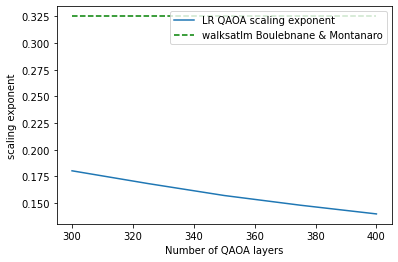

In [12]:
plt.plot(depths,exponents,label="LR QAOA scaling exponent")
#plt.hlines(y=b_ws, xmin=50, xmax=65, colors='r', label="walksat on the same subset",linestyle='--')
#plt.hlines(y=b_wslm, xmin=50, xmax=65, colors='b', label="walksatlm on the same subset",linestyle='--')
plt.hlines(y=0.325, xmin=300, xmax=400, colors='g', label="walksatlm Boulebnane & Montanaro",linestyle='--')
plt.ylabel("scaling exponent")
plt.xlabel("Number of QAOA layers")
plt.legend()